# Example to match sensitivities to RMG's SimpleReactor

In [1]:
import os
import rmgpy.chemkin
import rmgpy.solver
import rmgpy.rmg.listener
import rmgpy.rmg.settings

import cantera as ct

import numpy as np

import importlib
importlib.reload(rmgpy.tools.uncertainty)

import matplotlib.pyplot as plt
%matplotlib inline

# Load RMG Mechanism and specify reactor conditions for RMG and Cantera

In [2]:
chemkin = './superminimal/chem_annotated.inp'
spec_dict = './superminimal/species_dictionary.txt'
mech_yaml = chemkin.replace('.inp', '.yaml')

species_list, reaction_list = rmgpy.chemkin.load_chemkin_file(chemkin, spec_dict)


def get_i_thing(thing, thing_list):
    for i in range(len(thing_list)):
        if thing.is_isomorphic(thing_list[i]):
            return i
    assert False

O2 = species_list[get_i_thing(rmgpy.species.Species(smiles='[O][O]'), species_list)]
H2 = species_list[get_i_thing(rmgpy.species.Species(smiles='[H][H]'), species_list)]
H2O = species_list[get_i_thing(rmgpy.species.Species(smiles='O'), species_list)]
Ar = species_list[get_i_thing(rmgpy.species.Species(smiles='[Ar]'), species_list)]


T = rmgpy.quantity.Quantity(1500, 'K')
P = rmgpy.quantity.Quantity(1.0, 'bar')
initial_mole_fractions = {
    H2: 0.67,
    O2: 0.33,
}

termination = rmgpy.solver.TerminationTime(rmgpy.quantity.Quantity((0.1, 's')))
sensitive_species = []
sensitive_species = [H2, H2O]


# Run sensitivity analysis in RMG

In [3]:
# Set up a SimpleReactor
reaction_system = rmgpy.solver.simple.SimpleReactor(
    T,
    P,
    initial_mole_fractions=initial_mole_fractions,
    n_sims=1,
    sensitive_species=sensitive_species,
    sensitivity_threshold=1e-3,
    termination=[termination],
)

# Save the simulation and sensitivity results
output_directory = './'
os.makedirs(os.path.join(output_directory, 'solver'), exist_ok=True)
reaction_system_index = 0
sens_worksheet = []
for spec in sensitive_species:
    csvfile_path = os.path.join(output_directory, 'solver',
                                'sensitivity_{0}_SPC_{1}.csv'.format(reaction_system_index + 1, spec.index))
    sens_worksheet.append(csvfile_path)

reaction_system.attach(rmgpy.rmg.listener.SimulationProfileWriter(output_directory, reaction_system_index, species_list))
reaction_system.attach(rmgpy.rmg.listener.SimulationProfilePlotter(output_directory, reaction_system_index, species_list))


simulator_settings = rmgpy.rmg.settings.SimulatorSettings()  # defaults
model_settings = rmgpy.rmg.settings.ModelSettings(tol_move_to_core = 1e5)  # defaults

reaction_system.simulate(
    core_species=species_list,
    core_reactions=reaction_list,
    edge_species=[],
    edge_reactions=[],
    surface_species=[],
    surface_reactions=[],
    model_settings=model_settings,
    simulator_settings=simulator_settings,
    sensitivity=True,
    sens_worksheet=sens_worksheet,
)

# retrieve the data from the csv
# You could use pandas to get it more directly, but this is fine
simulation_outfile = os.path.join(output_directory, 'solver', f'simulation_1_{len(species_list):d}.csv')
times, data = rmgpy.tools.plot.parse_csv_data(simulation_outfile)
data_labels = [d.label for d in data]

# Run equivalent simulation in Cantera

In [4]:
gas = ct.Solution(mech_yaml)

# check that the species and reactions match up between RMG and Cantera
assert len(species_list) == gas.n_species
assert len(reaction_list) == gas.n_reactions

for i in range(gas.n_species):
    assert str(species_list[i].to_chemkin()) == str(gas.species_names[i])

def same_reaction(rmg_rxn, ct_rxn):
    # really hacky way to do this, but whatever
    rmg_r = set([str(x.to_chemkin()) for x in rmg_rxn.reactants])
    rmg_p = set([str(x.to_chemkin()) for x in rmg_rxn.products])
    rmg_r = rmg_r - set(['Ar'])
    rmg_p = rmg_p - set(['Ar'])
    rmg_val = list(set(sorted(list(rmg_r) + list(rmg_p))))
    
    ct_r = set(ct_rxn.reactants.keys())
    ct_p = set(ct_rxn.products.keys())
    ct_val = list(set(sorted(list(ct_r) + list(ct_p))))
    return ct_val == rmg_val

for i in range(gas.n_reactions):
    assert same_reaction(reaction_list[i], gas.reactions()[i])


REACTOR_VOLUME = 8.314 * T.value_si / P.value_si  # work with 1 mole of gas to match the simple reactor
initial_gas_mole_fractions_ct = {x.to_chemkin(): v for x, v in initial_mole_fractions.items()}

gas.TPX = T.value_si, P.value_si, initial_gas_mole_fractions_ct
gas_reactor = ct.IdealGasConstPressureReactor(gas, energy='off')
gas_reactor.volume = REACTOR_VOLUME

sim = ct.ReactorNet([gas_reactor])

times_ct = [sim.time]
volumes = [gas_reactor.volume]
pressures = [gas.P]
temperatures = [gas.T]
mass = gas_reactor.mass
mole_fracs = [gas.X]
mass_fracs = [gas.Y]

# Add all parameters for sensitivity
for i in range(gas.n_reactions):
    gas_reactor.add_sensitivity_reaction(i)
for i in range(gas.n_species):
    gas_reactor.add_sensitivity_species_enthalpy(i)

# We need all sensitivities (or sensitivities of interest + sensitivity in total # moles) to convert from mass sensitivity to molar sensitivity
all_sensitivities = [np.zeros((gas.n_species + gas.n_reactions, gas.n_species))]

sim.initialize()
while sim.time < termination.time.value_si:
    sim.step()
    times_ct.append(sim.time)
    volumes.append(gas_reactor.volume)
    pressures.append(gas.P)
    temperatures.append(gas.T)
    mole_fracs.append(gas.X)
    mass_fracs.append(gas.Y)

    sens_mat = np.zeros((gas.n_species + gas.n_reactions, gas.n_species))

    # record sensitivities
    for j in range(gas.n_species):
        for i in range(gas.n_reactions):  # gas reactions
            sens_mat[i, j] = sim.sensitivity(gas.species_names[j], i)
        for i in range(gas.n_species):  # gas species
            sens_mat[gas.n_reactions + i, j] = sim.sensitivity(gas.species_names[j], gas.n_reactions + i) * 4.184 * 1e6  # convert from J/kmol to kcal / mol in denominator    

    all_sensitivities.append(sens_mat)
    

times_ct = np.array(times_ct)
volumes = np.array(volumes)
pressures = np.array(pressures)
temperatures = np.array(temperatures)
mass_fracs = np.array(mass_fracs)
all_sensitivities = np.array(all_sensitivities)
mole_fracs = np.array(mole_fracs)

# Plot top concentrations to show simulations match

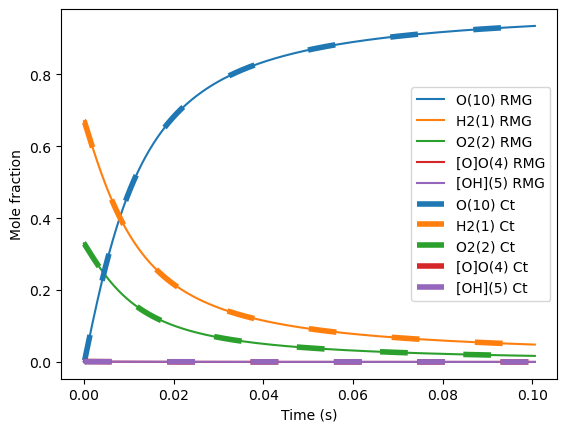

In [5]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# RMG
conc_data = np.array([d.data for d in data[1:]]).T
n_total = np.sum(conc_data, axis=1)
rmg_mole_fracs = np.divide(conc_data, n_total[:, np.newaxis])

max_conc = np.max(rmg_mole_fracs, axis=0)
indices = np.arange(conc_data.shape[1])
sorted_order = [x for _, x in sorted(zip(max_conc, indices))][::-1]

for i in range(5):
    j = sorted_order[i]
    plt.plot(times.data, rmg_mole_fracs[:, j], label=data_labels[j + 1] + ' RMG', color=colors[i % len(colors)])

# Cantera
max_conc = np.max(mole_fracs, axis=0)
indices = np.arange(mole_fracs.shape[1])
sorted_order = [x for _, x in sorted(zip(max_conc, indices))][::-1]
for i in range(5):
    j = sorted_order[i]
    plt.plot(times_ct, mole_fracs[:, j], label=gas.species_names[j] + ' Ct', linestyle=(0, (5, 10)), linewidth=4.0, color=colors[i% len(colors)])


plt.ylabel('Mole fraction')
plt.xlabel('Time (s)')
plt.legend()

# Plot sensitivity

Text(0.5, 0, 'Time (s)')

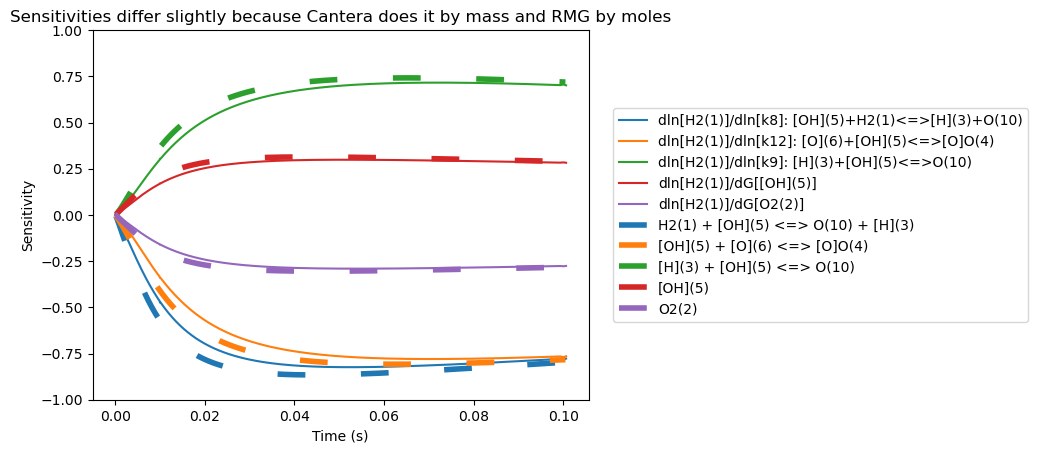

In [6]:
# RMG sensitivity results
top_N = 5

# Get the H2 results
i_H2 = species_list.index(H2)
H2_worksheet = f'./solver/sensitivity_1_SPC_{H2.index}.csv'
times1, data1 = rmgpy.tools.plot.parse_csv_data(H2_worksheet)
data_labels1 = [d.label for d in data1]
times1 = times1.data
s1_mat = np.array([d.data for d in data1]).T

max_sens = np.max(np.abs(s1_mat), axis=0)
indices = np.arange(s1_mat.shape[1])
sorted_order = [x for _, x in sorted(zip(max_sens, indices))][::-1]
for i in range(top_N):
    j = sorted_order[i]
    plt.plot(times1, s1_mat[:, j], label=data_labels1[j], color=colors[i % len(colors)])

# Cantera results
max_sens = np.max(np.abs(all_sensitivities[:, :, i_H2]), axis=0)
indices = np.arange(all_sensitivities.shape[1])
sorted_order_ct = [x for _, x in sorted(zip(max_sens, indices))][::-1]

ct_label = gas.reaction_equations() + gas.species_names

for i in range(top_N):
    j = sorted_order_ct[i]
    plt.plot(times_ct, all_sensitivities[:, j, i_H2], label=ct_label[j], linestyle=(0, (5, 10)), linewidth=4.0, color=colors[i % len(colors)])

plt.title('Sensitivities differ slightly because Cantera does it by mass and RMG by moles')
plt.legend(loc='right', bbox_to_anchor=(1.9, 0.5))
plt.ylim([-1, 1])
plt.ylabel('Sensitivity')
plt.xlabel('Time (s)')

# Sensitivities differ because RMG gives us:
$$S_{ik}=\frac{p_i}{y_k} \cdot \frac{\partial y_k}{\partial p_i}$$

# and Cantera gives us:
$$S_{ik}=\frac{p_i}{x_k} \cdot \frac{\partial x_k}{\partial p_i}$$

$S_{ik}$ is sensitivity of species $k$ to parameter $p_i$

$y_k$ is the mole fraction of species $k$

$x_k$ is the mass fraction of species $k$

$p_i$ is the $i$th parameter (species enthalpy or reaction rate coefficient)

We can convert from mass-based sensitivity to mole-based sensitivity as follows:

$$\frac{p_i}{y_k} \frac{\partial y_k}{\partial p_i} = \frac{1}{y_k} \cdot 
\frac{\left[\sum_j \frac{x_j}{W_j}\right] \cdot \frac{ x_k }{W_k} \left( \frac{p_i}{x_k} \frac{\partial x_k}{\partial p_i}\right) -
\frac{x_k }{W_k}\cdot   \left[ \sum_j \frac{x_j }{W_j} \left( \frac{p_i}{x_j}\frac{\partial x_j}{\partial p_i} \right)\right]  }
{\left( \sum_j \frac{x_j}{W_j} \right)^2}$$

But it requires getting the mass-based sensitivity for every species (or the total sensitivity of moles with respect to the parameters of interest $\frac{\partial N}{\partial p_i}$)

# Convert from Cantera's mass-based sensitivity to mole-based sensitivity

In [7]:
molecular_weights = gas.molecular_weights / 1000.0  # convert from kg/kmol to kg/mol
mol_sensitivities = np.zeros_like(all_sensitivities) + np.nan

for i in range(all_sensitivities.shape[1]):  # repeat over perturbed parameter p
    for k in range(all_sensitivities.shape[2]):  # repeat over sensitive species concentration y_k
        
        sum_xj_Wj = np.zeros(all_sensitivities.shape[0])
        for j in range(gas.n_species):
            sum_xj_Wj += mass_fracs[:, j] / molecular_weights[j]

        low_d_high = np.multiply(np.multiply(sum_xj_Wj, mass_fracs[:, k]), all_sensitivities[:, i, k] / molecular_weights[k])

        sum_xj_Winv_dx_dp = np.zeros(all_sensitivities.shape[0])
        for j in range(gas.n_species):
            sum_xj_Winv_dx_dp += np.multiply(mass_fracs[:, j], all_sensitivities[:, i, j] / molecular_weights[j])
        high_d_low = np.multiply(sum_xj_Winv_dx_dp, mass_fracs[:, k] / molecular_weights[k])

        mol_sensitivities[:, i, k] = np.divide(np.divide((low_d_high - high_d_low), np.float_power(sum_xj_Wj, 2.0)), mole_fracs[:, k])

    


/tmp/ipykernel_32502/1659135092.py:18: RuntimeWarning: invalid value encountered in divide
  mol_sensitivities[:, i, k] = np.divide(np.divide((low_d_high - high_d_low), np.float_power(sum_xj_Wj, 2.0)), mole_fracs[:, k])


### Plot sensitivities again using same basis

Text(0.5, 0, 'Time (s)')

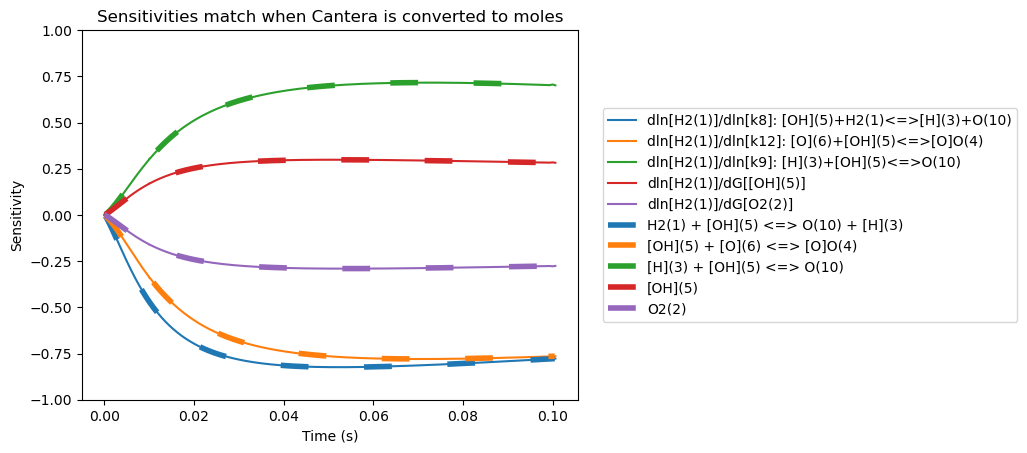

In [8]:
# RMG sensitivity results
top_N = 5

# Get the H2 results
i_H2 = species_list.index(H2)
H2_worksheet = f'./solver/sensitivity_1_SPC_{H2.index}.csv'
times1, data1 = rmgpy.tools.plot.parse_csv_data(H2_worksheet)
data_labels1 = [d.label for d in data1]
times1 = times1.data
s1_mat = np.array([d.data for d in data1]).T

max_sens = np.max(np.abs(s1_mat), axis=0)
indices = np.arange(s1_mat.shape[1])
sorted_order = [x for _, x in sorted(zip(max_sens, indices))][::-1]
for i in range(top_N):
    j = sorted_order[i]
    plt.plot(times1, s1_mat[:, j], label=data_labels1[j], color=colors[i % len(colors)])

# Cantera results
max_sens = np.max(np.abs(all_sensitivities[:, :, i_H2]), axis=0)
indices = np.arange(all_sensitivities.shape[1])
sorted_order_ct = [x for _, x in sorted(zip(max_sens, indices))][::-1]

ct_label = gas.reaction_equations() + gas.species_names

for i in range(top_N):
    j = sorted_order_ct[i]
    plt.plot(times_ct, mol_sensitivities[:, j, i_H2], label=ct_label[j], linestyle=(0, (5, 10)), linewidth=4, color=colors[i% len(colors)])

plt.title('Sensitivities match when Cantera is converted to moles')
plt.legend(loc='right', bbox_to_anchor=(1.9, 0.5))
plt.ylim([-1, 1])
plt.ylabel('Sensitivity')
plt.xlabel('Time (s)')

Text(0.5, 0, 'Time (s)')

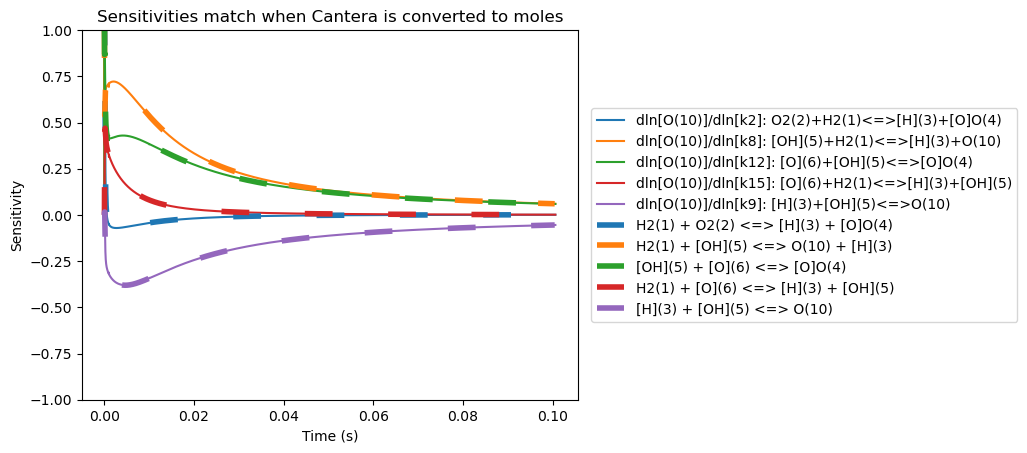

In [9]:
# RMG sensitivity results
top_N = 5

# Get the H2 results
i_H2O = species_list.index(H2O)
H2O_worksheet = f'./solver/sensitivity_1_SPC_{H2O.index}.csv'
times1, data1 = rmgpy.tools.plot.parse_csv_data(H2O_worksheet)
data_labels1 = [d.label for d in data1]
times1 = times1.data
s1_mat = np.array([d.data for d in data1]).T

max_sens = np.max(np.abs(s1_mat), axis=0)
indices = np.arange(s1_mat.shape[1])
sorted_order = [x for _, x in sorted(zip(max_sens, indices))][::-1]
for i in range(top_N):
    j = sorted_order[i]
    plt.plot(times1, s1_mat[:, j], label=data_labels1[j], color=colors[i % len(colors)])

# Cantera results
max_sens = np.max(np.abs(all_sensitivities[:, :, i_H2O]), axis=0)
indices = np.arange(all_sensitivities.shape[1])
sorted_order_ct = [x for _, x in sorted(zip(max_sens, indices))][::-1]

ct_label = gas.reaction_equations() + gas.species_names

for i in range(top_N):
    j = sorted_order_ct[i]
    plt.plot(times_ct, mol_sensitivities[:, j, i_H2O], label=ct_label[j], linestyle=(0, (5, 10)), linewidth=4, color=colors[i% len(colors)])

plt.title('Sensitivities match when Cantera is converted to moles')
plt.legend(loc='right', bbox_to_anchor=(1.9, 0.5))
plt.ylim([-1, 1])
plt.ylabel('Sensitivity')
plt.xlabel('Time (s)')